## Project Objectives:

1. Accept a configurable budget (e.g., \\$1K or \\$100K)
2. Use Dollar-Cost Averaging (DCA) to accumulate more bitcoin when prices drop, distributing buys over time or price levels
3. Implement an ATR-based stop-loss strategy to manage short-term trades and avoid excessive loss exposure
4. Switch between different strategies (e.g., day trading, swing trading, value investing)
5. Adapt continuously to market conditions, ideally with the help of a lightweight LLM
6. Run 24/7 and deploy in a cloud environment
7. Send Telegram notifications for each trade made
8. Send a weekly email report every Monday at 9:00AM via Gmail

In [2]:
# Import necessary libraries

import sys
import os
import json
import pandas as pd
import numpy as np
from datetime import datetime, timedelta, timezone
from pathlib import Path
import warnings
import requests
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
from typing import Any

In [3]:
# Get historical BTC data from Coinbase API

def get_btc_historical_candles(product_id = "BTC-USD", granularity = 86400, days_back = 300):
    
    end_time = datetime.now(timezone.utc)
    start_time = end_time - timedelta(days=days_back)

    url = f"https://api.exchange.coinbase.com/products/{product_id}/candles"
    params = {"start": start_time.isoformat().replace("+00:00", "Z"),
                "end": end_time.isoformat().replace("+00:00", "Z"),
                "granularity": granularity}

    response = requests.get(url, params = params, timeout = 20)
    response.raise_for_status()
    rows = response.json()

    candles = []
    for row in rows:
        candles.append({ "time": datetime.fromtimestamp(row[0], tz=timezone.utc),
                        "low": float(row[1]), "high": float(row[2]), "open": float(row[3]),
                        "close": float(row[4]), "volume":float(row[5])})

    candles.sort(key = lambda x: x["time"])
    candles_df = pd.DataFrame(candles)

    return candles_df

In [4]:
# Calculate ATR

def calculate_atr(candles_df, window = 14):

    df = candles_df.copy()
    df["prev_close"] = df["close"].shift(1)

    df["tr1"] = df["high"] - df["low"]
    df["tr2"] = (df["high"] - df["prev_close"]).abs()
    df["tr3"] = (df["low"] - df["prev_close"]).abs()

    df["true_range"] = df[["tr1", "tr2", "tr3"]].max(axis=1)
    df["ATR"] = df["true_range"].rolling(window).mean()

    return df

In [5]:
# Plot BTC closing price and ATR

def plot_price_and_atr(df):

    # Ensure datetime format
    df["time"] = pd.to_datetime(df["time"])

    # Create figure
    plt.figure(figsize=(12, 8))

    # Plot BTC Price
    plt.subplot(2, 1, 1)
    plt.plot(df["time"], df["close"])
    plt.title("Bitcoin Price (Close)")
    plt.xlabel("Time")
    plt.ylabel("Price (USD)")

    # Plot ATR
    plt.subplot(2, 1, 2)
    plt.plot(df["time"], df["ATR"])
    plt.title("Average True Range (ATR)")
    plt.xlabel("Time")
    plt.ylabel("ATR (USD)")
    
    plt.tight_layout()
    plt.show()

In [6]:
# Create ATR-based profit-taking targets for a position

def build_profit_targets(entry_price, atr_at_entry, atr_levels, sell_fractions):

    targets = []
    for atr_level, sell_fraction in zip(atr_levels, sell_fractions):
        targets.append({"atr_level":atr_level, 
                       "target_price": entry_price + (atr_level * atr_at_entry),
                        "sell_fraction": sell_fraction,
                        "triggered": False,
                        "btc_sold": 0.0})

    return targets

In [7]:
# Create DCA strategy with stop-loss and profit-taking mechanism

def run_dca_strategy(candles_df, total_budget = 10000.0, buy_amount = 500.0,
                    drop_trigger_pct = 0.03, atr_stop_multiple = 2.0,
                    atr_take_profit_levels = [1.0, 2.0, 3.0], 
                    atr_take_profit_fractions = [0.25, 0.25, 0.50]):
    """
    Strategy rules:
    1. Buy $500 of BTC whenever closing price drops 3% from current reference price.
    2. After each buy stop_loss = entry_price - atr_stop_multiple * ATR
    3. Set sell target price for taking profit using ATR
    4. Trigger exits using candle low and high
        - stop-loss if low <= stop_loss
        - take profit if high >= target_price
    5. Execute stop-loss first in case loss and target are both reached in the same candle
    """
    df = candles_df.copy().sort_values("time").reset_index(drop=True)

    remaining_cash = total_budget
    reference_price = float(df.loc[0, "close"])

    open_positions = []
    buy_events = []
    sell_events = []

    for idx, row in df.iterrows():
        current_time = row["time"]
        candle_open = row["open"]
        candle_high = row["high"]
        candle_low = row["low"]
        candle_close = row["close"]
        current_atr = float(row["ATR"]) if pd.notna(row["ATR"]) else None

        # Reset the reference price if closing price is higher than the current reference price
        if candle_close > reference_price:
            reference_price = candle_close
        
        for pos in open_positions:

            # Check of BTC balance is positive
            if pos["btc_remaining"] <= 0:
                continue

            # Check if BTC price has hit the stop loss limit
            stop_hit = (candle_low <= pos["stop_loss"])

            # Fetch price targets for selling BTC
            hit_targets = []
            
            for target in pos["targets"]:
                if (not target["triggered"]) and (candle_high >= target["target_price"]):
                    hit_targets.append(target)
       
            # Case 1: Stop loss triggers first if both stop and profit-taking targets are hit in the same candle
            if stop_hit:
                btc_to_sell = pos["btc_remaining"]
                exit_price = pos["stop_loss"]
                usd_received = btc_to_sell * exit_price
                pnl = usd_received - (btc_to_sell * pos["entry_price"])

                pos["btc_remaining"] = 0.0
                remaining_cash += usd_received

                sell_events.append({"time": current_time, "type": "stop_loss",
                                "position_id": pos["position_id"], "entry_time": pos["buy_time"],
                                "entry_price": pos["entry_price"], "exit_price": exit_price,
                                "btc_sold": btc_to_sell, "usd_received": usd_received,
                                "pnl": pnl, "atr_at_entry": pos["atr_at_entry"],
                                "atr_level": None, "target_price": None,
                                "stop_loss": pos["stop_loss"], "remaining_cash": remaining_cash,
                                "btc_remaining_in_position": 0.0,
                                "note": "Assumed stop loss first over profit target"})
                continue

            # Case 2: Take profit when target is hit
            if hit_targets:
                hit_targets = sorted(hit_targets, key = lambda t: t["target_price"])

                for target in hit_targets:
                    if pos["btc_remaining"] <= 0:
                        break
                    if target["triggered"]:
                        continue

                    btc_to_sell = pos["initial_btc"] * target["sell_fraction"]
                    btc_to_sell = min(btc_to_sell, pos["btc_remaining"])

                    exit_price = target["target_price"]
                    usd_received = btc_to_sell * exit_price
                    pnl = usd_received - (btc_to_sell * pos["entry_price"])

                    pos["btc_remaining"] -= btc_to_sell
                    remaining_cash += usd_received
                    target["triggered"] = True
                    target["btc_sold"] = btc_to_sell

                    sell_events.append({"time": current_time, "type": "take_profit",
                                        "position_id": pos["position_id"], "entry_time": pos["buy_time"],
                                        "entry_price": pos["entry_price"], "exit_price": exit_price,
                                        "btc_sold": btc_to_sell, "usd_received": usd_received,
                                        "pnl": pnl, "atr_at_entry": pos["atr_at_entry"],
                                        "atr_level": target["atr_level"], "target_price": target["target_price"],
                                        "stop_loss": pos["stop_loss"], "remaining_cash": remaining_cash,
                                        "btc_remaining_in_position": pos["btc_remaining"], "note": ""})
                    
        # Case 3: DCA buy logic
        drawdown = (reference_price - candle_close) / reference_price
        buy_triggered = (drawdown >= drop_trigger_pct)
        enough_cash = (remaining_cash >= buy_amount)
        atr_available = current_atr is not None

        if buy_triggered and enough_cash and atr_available:
            btc_bought = buy_amount / candle_close
            stop_loss = candle_close - (atr_stop_multiple * current_atr)

            position_id = len(buy_events) + 1
            targets = build_profit_targets(entry_price = candle_close, atr_at_entry = current_atr, atr_levels = atr_take_profit_levels,
                                               sell_fractions = atr_take_profit_fractions)

            position = {"position_id": position_id, "buy_time": current_time, "entry_price": candle_close,
                            "atr_at_entry": current_atr, "stop_loss": stop_loss, "initial_btc": btc_bought,
                            "btc_remaining": btc_bought, "usd_invested": buy_amount, "targets": targets}

            open_positions.append(position)
            remaining_cash -= buy_amount

            buy_events.append({"time": current_time, "position_id": position_id, "entry_price": candle_close,
                                   "usd_spent": buy_amount, "btc_bought": btc_bought, "atr_at_entry": current_atr,
                                   "stop_loss": stop_loss, "drawdown_pct": drawdown * 100, "remaining_cash": remaining_cash})

            reference_price = candle_close
        
    
    live_positions = [p for p in open_positions if p["btc_remaining"] > 0]
    last_close = float(df.iloc[-1]["close"])

    open_rows = []
    for pos in live_positions:
        market_value = pos["btc_remaining"] * last_close
        unrealized_pnl = market_value - (pos["btc_remaining"] * pos["entry_price"])
        
        open_rows.append({"position_id": pos["position_id"], "buy_time": pos["buy_time"], "entry_price": pos["entry_price"],
                          "atr_at_entry": pos["atr_at_entry"], "stop_loss": pos["stop_loss"], "initial_btc": pos["initial_btc"],
                          "btc_remaining": pos["btc_remaining"], "usd_invested": pos["usd_invested"], "market_price": last_close,
                          "market_value": pos["btc_remaining"] * last_close,
                          "unrealized_pnl": unrealized_pnl})

    buys_df = pd.DataFrame(buy_events)
    sells_df = pd.DataFrame(sell_events)
    open_df = pd.DataFrame(open_rows)

    total_realized_pnl = 0.0 if sells_df.empty else float(sells_df["pnl"].sum())
    total_open_value = 0.0 if open_df.empty else float(open_df["market_value"].sum())
    total_unrealized_pnl = 0.0 if open_df.empty else float(open_df["unrealized_pnl"].sum())
    total_equity = remaining_cash + total_open_value

    summary = {"starting_budget": total_budget, "remaining_cash": remaining_cash,
               "open_position_value": total_open_value, "total_equity": total_equity,
               "realized_pnl": total_realized_pnl, "unrealized_pnl": total_unrealized_pnl,
               "total_pnl": total_realized_pnl + total_unrealized_pnl,
               "number_of_buys": 0 if buys_df.empty else len(buys_df),
               "number_of_sells": 0 if sells_df.empty else len(sells_df),
               "number_of_open_positions": 0 if open_df.empty else len(open_df),
               "last_btc_price": last_close}

    return buys_df, sells_df, open_df, summary  


Imported BTC data
                       time        low       high       open      close  \
0 2025-06-25 00:00:00+00:00  105875.00  108206.00  106141.01  107400.22   
1 2025-06-26 00:00:00+00:00  106605.88  108345.00  107400.22  107029.64   
2 2025-06-27 00:00:00+00:00  106413.79  107804.20  107029.63  107113.38   
3 2025-06-28 00:00:00+00:00  106868.94  107599.81  107119.17  107352.20   
4 2025-06-29 00:00:00+00:00  107230.00  108550.00  107352.20  108386.44   

        volume  
0  7072.656363  
1  4900.222317  
2  6310.437157  
3  1227.768033  
4  2154.861703  

BTC ATR values
                        time        low       high       open      close  \
14 2025-07-09 00:00:00+00:00  108329.87  112152.91  108953.58  111282.85   
15 2025-07-10 00:00:00+00:00  110541.87  116842.00  111282.84  116031.30   
16 2025-07-11 00:00:00+00:00  115211.74  118909.74  116031.29  117582.16   
17 2025-07-12 00:00:00+00:00  116940.82  118244.51  117582.16  117472.65   
18 2025-07-13 00:00:00+00:00  11

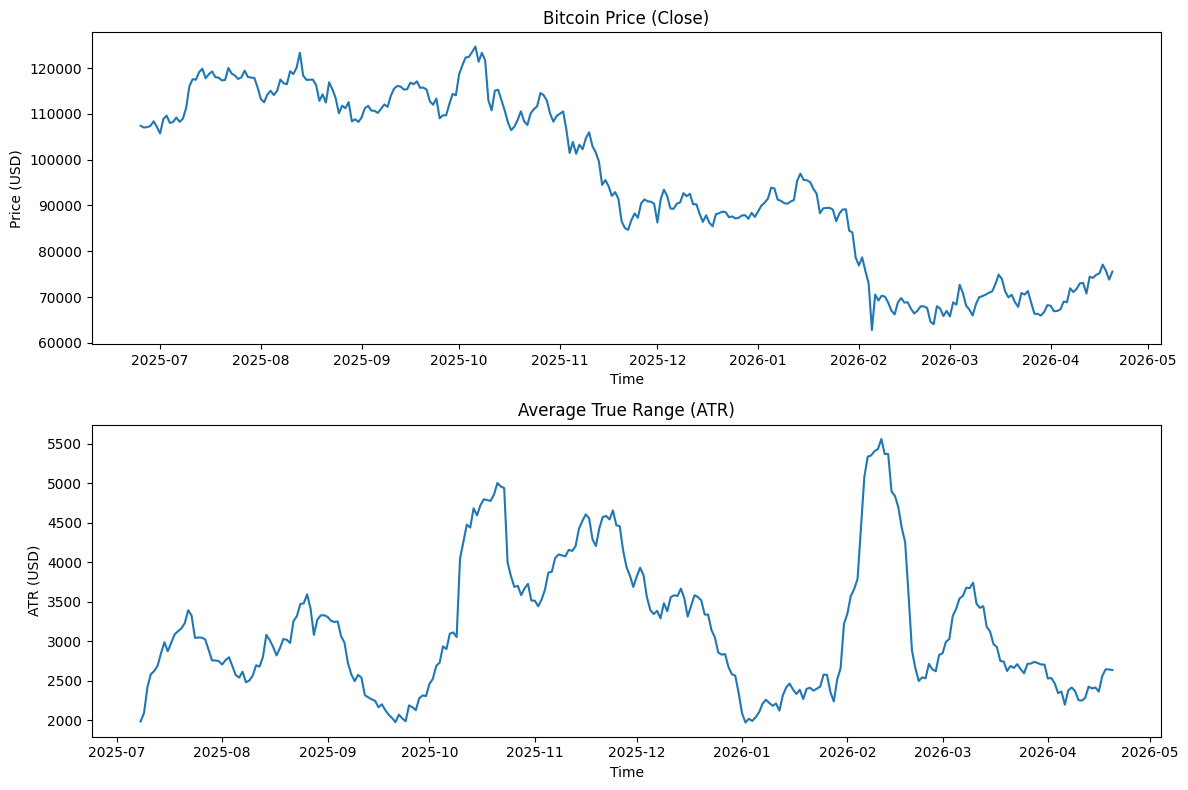


ATR targets
   atr_level   target_price  sell_fraction  triggered  btc_sold
0          1  113374.384286           0.25      False       0.0
1          2  115465.918571           0.25      False       0.0
2          3  117557.452857           0.50      False       0.0

Trading Straetgy Ouptut

Buy Events


,time,position_id,entry_price,usd_spent,btc_bought,atr_at_entry,stop_loss,drawdown_pct,remaining_cash
0,2025-07-31 00:00:00+00:00,1,115761.13,500.0,0.004319,2749.307857,110262.514286,3.553626,9500.000000
1,2025-08-14 00:00:00+00:00,2,118389.79,500.0,0.004223,3080.993571,112227.802857,4.033409,9526.718566
2,2025-08-19 00:00:00+00:00,3,112856.19,500.0,0.004430,3027.877857,106800.434286,4.674052,9026.718566
3,2025-08-25 00:00:00+00:00,4,110127.74,500.0,0.004540,3479.884286,103167.971429,5.800202,9129.048107
4,2025-08-29 00:00:00+00:00,5,108378.32,500.0,0.004613,3273.278571,101831.762857,3.727769,8629.048107



Sell Events


,time,type,position_id,entry_time,entry_price,exit_price,btc_sold,usd_received,pnl,atr_at_entry,atr_level,target_price,stop_loss,remaining_cash,btc_remaining_in_position,note
0,2025-08-10 00:00:00+00:00,take_profit,1,2025-07-31 00:00:00+00:00,115761.13,118510.437857,0.001080,127.968730,2.968730,2749.307857,1.0,118510.437857,110262.514286,9627.968730,0.003239,
1,2025-08-11 00:00:00+00:00,take_profit,1,2025-07-31 00:00:00+00:00,115761.13,121259.745714,0.001080,130.937459,5.937459,2749.307857,2.0,121259.745714,110262.514286,9758.906189,0.002160,
2,2025-08-14 00:00:00+00:00,take_profit,1,2025-07-31 00:00:00+00:00,115761.13,124009.053571,0.002160,267.812377,17.812377,2749.307857,3.0,124009.053571,110262.514286,10026.718566,0.000000,
3,2025-08-21 00:00:00+00:00,stop_loss,2,2025-08-14 00:00:00+00:00,118389.79,112227.802857,0.004223,473.975851,-26.024149,3080.993571,NaN,NaN,112227.802857,9500.694416,0.000000,Assumed stop loss first over profit target
4,2025-08-22 00:00:00+00:00,take_profit,3,2025-08-19 00:00:00+00:00,112856.19,115884.067857,0.001108,128.353690,3.353690,3027.877857,1.0,115884.067857,106800.434286,9629.048107,0.003323,



Open Positions


,position_id,buy_time,entry_price,atr_at_entry,stop_loss,initial_btc,btc_remaining,usd_invested,market_price,market_value,unrealized_pnl
0,30,2026-02-05 00:00:00+00:00,62791.00,4443.031429,53904.937143,0.007963,8.673617e-19,500.0,75558.28,6.553636e-14,1.107385e-14
1,31,2026-02-11 00:00:00+00:00,67024.93,5561.147143,55902.635714,0.007460,3.729955e-03,500.0,75558.28,2.818290e+02,3.182901e+01
2,32,2026-02-17 00:00:00+00:00,67466.70,4437.012857,58592.674286,0.007411,3.705532e-03,500.0,75558.28,2.799836e+02,2.998361e+01
3,34,2026-02-27 00:00:00+00:00,65859.94,2620.364286,60619.211429,0.007592,4.336809e-19,500.0,75558.28,3.276818e-14,4.205985e-15
4,35,2026-03-06 00:00:00+00:00,68108.24,3541.044286,61026.151429,0.007341,3.670628e-03,500.0,75558.28,2.773463e+02,2.734632e+01



Summary
starting_budget: 10000.000000
remaining_cash: 8915.468891
open_position_value: 1350.910952
total_equity: 10266.379843
realized_pnl: 165.468891
unrealized_pnl: 100.910952
total_pnl: 266.379843
number_of_buys: 42
number_of_sells: 93
number_of_open_positions: 9
last_btc_price: 75558.280000


In [8]:
if __name__ == "__main__":
    
    # Fetch BTC data from Coinbase API
    candles_df = get_btc_historical_candles(product_id = "BTC-USD", granularity = 86400, 
                                            days_back = 300)
    print("\nImported BTC data")
    print(candles_df.head())

    # Calculate ATR
    candles_df = calculate_atr(candles_df, window = 14)
    
    print("\nBTC ATR values")
    print(candles_df.iloc[14:19])

    # Plot BTC price and ATR
    plot_price_and_atr(candles_df)

    # Create ATR-based targets for a position
    entry_price = candles_df["close"][14]
    atr_at_entry = candles_df["ATR"][14]
    atr_levels = [1, 2, 3]
    sell_fractions = [0.25, 0.25, 0.50]

    targets = build_profit_targets(entry_price, atr_at_entry, atr_levels, sell_fractions)
    
    print("\nATR targets")
    print(pd.DataFrame(targets))

    # Run DCA + stop loss + profit taking strategy
    buys_df, sells_df, open_df, summary = run_dca_strategy(candles_df, total_budget = 10000.0, buy_amount = 500.0,
                    drop_trigger_pct = 0.03, atr_stop_multiple = 2.0,
                    atr_take_profit_levels = [1.0, 2.0, 3.0], 
                    atr_take_profit_fractions = [0.25, 0.25, 0.50])

    print("\nTrading Straetgy Ouptut")
    print("\nBuy Events")
    if buys_df.empty:
        print("No buys triggered")
    else:
        display(buys_df.head())

    print("\nSell Events")
    if sells_df.empty:
        print("No sell triggered")
    else:
        display(sells_df.head())

    print("\nOpen Positions")
    if open_df.empty:
        print("No open position")
    else:
        display(open_df.head())

    print("\nSummary")
    for key, value in summary.items():
        if isinstance(value, float):
            print(f"{key}: {value:.6f}")
        else:
            print(f"{key}: {value}")